Environment & Dependency Setup

In [ ]:
import sys
!{sys.executable} -m pip install transformers torch tqdm pandas numpy

Combine features from all models

In [32]:
import os
import json
import zipfile
import pandas as pd
import numpy as np
from tqdm import tqdm
import re

# ==========================================
# 1. SETUP & RELATIVE PATHS
# ==========================================
# This makes the code work on ANY machine without changing the path
BASE_DIR = os.getcwd()  

# Folders must be located in the same directory as this script
AF3_DIR = os.path.join(BASE_DIR, "3seed_AF3")
BIPSPI_ROOT = os.path.join(BASE_DIR, "BIPSPI_outputs")
ROSETTA_FILE = os.path.join(BASE_DIR, "output_binding_energies.csv")
OUTPUT_FILE = os.path.join(BASE_DIR, "FeatureExtracted_DATA - Step 1.csv")

def get_pdb_code(text):
    if not isinstance(text, str): return None
    # Regular expression to catch 4-character PDB IDs
    match = re.search(r'([0-9][A-Z0-9]{3})', text.upper())
    return match.group(1) if match else None

# ==========================================
# 2. PRE-LOAD EXTERNAL DATA
# ==========================================
print("📂 Indexing BIPSPI results...")
bipspi_db = {}
if os.path.exists(BIPSPI_ROOT):
    for root, dirs, files in os.walk(BIPSPI_ROOT):
        pdb = get_pdb_code(os.path.basename(root))
        if not pdb: continue
        for fn in files:
            if fn in ['PRED.res.tab.gz', 'PRED.res.tab']:
                try:
                    b_df = pd.read_table(os.path.join(root, fn), sep=r'\s+', 
                                        compression='gzip' if 'gz' in fn else None)
                    bipspi_db[pdb] = {
                        'L': b_df.groupby('resIdL')['prediction'].max().to_dict(),
                        'R': b_df.groupby('resIdR')['prediction'].max().to_dict()
                    }
                except: continue

print("📂 Indexing Rosetta Binding Energies...")
rosetta_map = {}
if os.path.exists(ROSETTA_FILE):
    rdf = pd.read_csv(ROSETTA_FILE)
    for _, row in rdf.iterrows():
        # Look for PDB code in the 'Proteins' column
        pdb = get_pdb_code(str(row.get('Proteins', '')))
        if pdb:
            rosetta_map[pdb] = row.get('del_G_B', np.nan)

# ==========================================
# 3. HELPER FUNCTION TO PROCESS DATA
# ==========================================
def process_af3_data(pdb, l_json, j_json, s_json, r_map, b_db):
    rows = []
    seq_list = []
    # Extract protein/RNA sequences
    for entry in j_json[0]['sequences']:
        if 'proteinChain' in entry: seq_list.append(entry['proteinChain']['sequence'])
        elif 'rnaChain' in entry: seq_list.append(entry['rnaChain']['sequence'])

    t_chains = l_json['token_chain_ids']
    t_res = l_json['token_res_ids']
    plddt = l_json.get('token_plddt', l_json.get('atom_plddts', [np.nan]*len(t_chains)))
    pae = np.array(l_json.get('pae', []))
    contact = np.array(l_json.get('contact_probs', []))

    unique_cids = sorted(list(set(t_chains)))
    cid_to_idx = {cid: i for i, cid in enumerate(unique_cids)}

    b_score_map = {}
    if pdb in b_db:
        for side, chains in [('L', unique_cids[:-1]), ('R', [unique_cids[-1]])]:
            offset = 0
            for c in chains:
                c_len = len([tid for tid in t_chains if tid == c])
                for r_id in range(1, c_len + 1):
                    b_score_map[(c, r_id)] = b_db[pdb][side].get(offset + r_id - 1, 0)
                offset += c_len

    complex_dg = r_map.get(pdb, np.nan)

    for i in range(len(t_chains)):
        c_val, r_id = t_chains[i], int(t_res[i])
        c_idx = cid_to_idx[c_val]
        try: aa = seq_list[c_idx][r_id - 1]
        except: aa = 'X'

        # Inter-chain indices only
        others = [j for j, val in enumerate(t_chains) if val != c_val]

        ipae_min = np.min(pae[i, others]) if others and pae.size > 0 else np.nan
        ipae_mean = np.mean(pae[i, others]) if others and pae.size > 0 else np.nan
        cp_max = np.max(contact[i, others]) if others and contact.size > 0 else 0

        rows.append({
            'complex_id': pdb,
            'chain': chr(65 + c_idx),
            'residue': r_id,
            'amino_acid': aa,
            'af3_plddt': plddt[i],
            'af3_ipae_min': ipae_min,
            'af3_ipae_mean': ipae_mean,
            'af3_contact_prob_max': cp_max,
            'iptm': s_json.get('iptm', 0),
            'ptm': s_json.get('ptm', 0),
            'ranking_score': s_json.get('ranking_score', 0),
            'rosetta_dg': complex_dg,
            'bipspi_score': b_score_map.get((c_val, r_id), 0)
        })
    return rows

# ==========================================
# 4. MAIN DEEP-SCAN LOOP (ALL MODELS 0-4)
# ==========================================
print(f"📂 Deep-scanning {AF3_DIR} for all ranked models...")
all_rows = []

if not os.path.exists(AF3_DIR):
    print(f"❌ AF3 folder not found at: {AF3_DIR}")
else:
    zip_files = [f for f in os.listdir(AF3_DIR) if f.endswith('.zip')]

    for z_fn in tqdm(zip_files, desc="Processing Zips"):
        z_path = os.path.join(AF3_DIR, z_fn)
        with zipfile.ZipFile(z_path, 'r') as z:
            files_by_dir = {}
            for name in z.namelist():
                parent = os.path.dirname(name)
                if parent not in files_by_dir: files_by_dir[parent] = []
                files_by_dir[parent].append(name)

            for folder, contents in files_by_dir.items():
                j_json_files = [c for c in contents if 'job_request.json' in c]
                if not j_json_files: continue
                
                # Identify all 5 models (0-4)
                full_data_files = [c for c in contents if 'full_data_' in c and c.endswith('.json')]
                
                for f_file in full_data_files:
                    try:
                        suffix = f_file.split('full_data_')[-1]
                        idx = suffix.split('.')[0]
                        s_file = next((c for c in contents if f'summary_confidences_{idx}.json' in c), None)
                        
                        if s_file:
                            pdb = get_pdb_code(folder) or get_pdb_code(z_fn)
                            with z.open(f_file) as f: ld = json.load(f)
                            with z.open(j_json_files[0]) as f: jd = json.load(f)
                            with z.open(s_file) as f: sd = json.load(f)

                            all_rows.extend(process_af3_data(pdb, ld, jd, sd, rosetta_map, bipspi_db))
                    except: continue

# ==========================================
# 5. EXPORT
# ==========================================
if all_rows:
    df = pd.DataFrame(all_rows)
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"\n✅ INTEGRATION COMPLETE")
    print(f"📊 Processed {df['complex_id'].nunique()} complexes with all models (0-4).")
    print(f"📁 Output: {OUTPUT_FILE}")
else:
    print("❌ No valid data found in the ZIP files.")

📂 Indexing BIPSPI results...
📂 Indexing Rosetta Binding Energies...
📂 Deep-scanning c:\Users\aramc\Desktop\PPI_Final_Pipeline\3seed_AF3 for all ranked models...


Processing Zips: 100%|██████████| 7/7 [00:29<00:00,  4.27s/it]



✅ INTEGRATION COMPLETE
📊 Processed 103 complexes with all models (0-4).
📁 Output: c:\Users\aramc\Desktop\PPI_Final_Pipeline\FeatureExtracted_DATA - Step 1.csv


Generate ESM-2 Embeddings for all Complexes

In [33]:
import os
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, EsmModel
import warnings
import logging
import os

# 1. Hide standard Python warnings
warnings.filterwarnings("ignore")

# 2. Hide Hugging Face/Transformers loading warnings
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

# 3. Hide the Symlink warning specifically
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# 4. (Optional) Disable the unauthenticated request warning
# Only do this if you aren't hitting rate limits
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "False"

# ==========================================
# 1. SETUP & LOCAL PATHS
# ==========================================
# This matches the relative pathing from your integration script
BASE_DIR = os.getcwd() 
INPUT_FILE = os.path.join(BASE_DIR, "FeatureExtracted_DATA - Step 1.csv")
OUTPUT_CSV = os.path.join(BASE_DIR, "ESM_READY_DATA - Step 2.csv")
OUTPUT_NPY = os.path.join(BASE_DIR, "esm2_embeddings_650M - Step 2.npy")

# ==========================================
# 2. LOAD MODEL (ESM-2 650M)
# ==========================================
model_name = "facebook/esm2_t33_650M_UR50D"
print(f"🚀 Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name)

# Use GPU and Half-Precision (FP16) for speed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
if torch.cuda.is_available():
    model = model.half() 
model.eval()

# ==========================================
# 3. PREPARE UNIQUE SEQUENCES
# ==========================================
print("🧬 Loading and deduplicating sequences...")
df = pd.read_csv(INPUT_FILE)

# IMPORTANT: We drop duplicates of (complex, chain, residue) 
# so we only have ONE copy of each unique chain to embed.
df_unique = df.drop_duplicates(subset=['complex_id', 'chain', 'residue'])

# Group residues into strings
complex_groups = df_unique.groupby(['complex_id', 'chain'])['amino_acid'].apply(
    lambda x: "".join(x.astype(str))
).reset_index()

# This dictionary stores the embedding matrix for each unique (complex, chain)
embedding_dict = {}

# ==========================================
# 4. GENERATION LOOP (Unique Chains Only)
# ==========================================
print(f"🧠 Generating Embeddings on {device}...")
with torch.no_grad():
    for _, row in tqdm(complex_groups.iterrows(), total=len(complex_groups)):
        cid = row['complex_id']
        chn = row['chain']
        sequence = row['amino_acid']

        # Tokenize sequence
        inputs = tokenizer(sequence, return_tensors="pt", padding=False, truncation=False)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Forward pass
        outputs = model(**inputs)

        # Get hidden states: [1, seq_len + 2, 1280]
        # Remove CLS (index 0) and EOS (last index) to match original residue count
        full_matrix = outputs.last_hidden_state.cpu().numpy()
        seq_embeddings = full_matrix[0, 1:-1, :]

        embedding_dict[(cid, chn)] = seq_embeddings.astype(np.float32)

# ==========================================
# 5. ALIGNMENT (Mapping to EVERY seed and model)
# ==========================================
print("🔗 Mapping unique embeddings back to all seeds/models...")
final_list = []
valid_indices = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    key = (row['complex_id'], row['chain'])
    # AF3 residues are 1-indexed, so we subtract 1 for the array index
    res_idx = int(row['residue']) - 1

    try:
        # Pull the specific 1280-d vector for this residue
        # This correctly maps the same vector to every seed of the same protein
        res_vector = embedding_dict[key][res_idx]
        final_list.append(res_vector)
        valid_indices.append(i)
    except (IndexError, KeyError):
        continue

# ==========================================
# 6. EXPORT
# ==========================================
final_matrix = np.array(final_list)
np.save(OUTPUT_NPY, final_matrix)

# Save the synchronized CSV
df_final = df.iloc[valid_indices].copy()
df_final.to_csv(OUTPUT_CSV, index=False)

print("\n" + "="*40)
print(f"✅ ESM-2 PIPELINE COMPLETE")
print(f"📁 Embedding Matrix: {OUTPUT_NPY}")
print(f"📁 Synchronized CSV: {OUTPUT_CSV}")
print(f"📊 Final Matrix Shape: {final_matrix.shape}")
print("="*40)

🚀 Loading facebook/esm2_t33_650M_UR50D...


Loading weights: 100%|██████████| 566/566 [00:00<00:00, 15460.00it/s]


🧬 Loading and deduplicating sequences...
🧠 Generating Embeddings on cpu...


100%|██████████| 223/223 [00:48<00:00,  4.59it/s]


🔗 Mapping unique embeddings back to all seeds/models...


100%|██████████| 397475/397475 [00:04<00:00, 85133.99it/s]



✅ ESM-2 PIPELINE COMPLETE
📁 Embedding Matrix: c:\Users\aramc\Desktop\PPI_Final_Pipeline\esm2_embeddings_650M - Step 2.npy
📁 Synchronized CSV: c:\Users\aramc\Desktop\PPI_Final_Pipeline\ESM_READY_DATA - Step 2.csv
📊 Final Matrix Shape: (397475, 1280)


Combine Ground Truth with all Features

In [34]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# ==========================================
# 1. SETUP & PATHS
# ==========================================
FEATURE_FILE = "ESM_READY_DATA - Step 2.csv"
TRUTH_FILE = "MASTER_GROUND_TRUTH.csv"
OUTPUT_FILE = "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv"

# THE TRANSLATION MAP
CHAIN_MAPPING = {
    '7CZX': {'A': ['H', 'L'], 'B': ['B']},
    '7LS9': {'A': ['H', 'L'], 'B': ['A']},
    '7CZQ': {'A': ['H', 'L'], 'B': ['A']},
    '7D0D': {'A': ['H', 'L'], 'B': ['A']},
    '7DET': {'A': ['B', 'C'], 'B': ['A']},
    '7MSQ': {'A': ['H', 'L'], 'B': ['A']},
    '7X8P': {'A': ['B', 'C'], 'B': ['A']}
}

# ==========================================
# 2. LOAD & PREPARE
# ==========================================
print("📂 Loading data...")
df_feats = pd.read_csv(FEATURE_FILE)
df_truth = pd.read_csv(TRUTH_FILE)

# FIX: Added .str before .upper()
df_feats['match_id'] = df_feats['complex_id'].str[:4].str.upper()
df_truth['pdb_id'] = df_truth['pdb_id'].astype(str).str.upper()

# ==========================================
# 3. THE FLEXIBLE MERGE
# ==========================================
print("🔗 Aligning features to PDB truth...")

# Create a fast lookup dictionary for the truth data
# Key: (PDB_ID, Chain, Residue) -> Truth
truth_lookup = {}
for _, row in df_truth.iterrows():
    # Ensure chain and residue are treated correctly
    key = (str(row['pdb_id']), str(row['pdb_chain']), int(row['residue']))
    truth_lookup[key] = row['ground_truth']

all_labels = []

for i, row in tqdm(df_feats.iterrows(), total=len(df_feats)):
    pdb = row['match_id']
    f_chain = str(row['chain'])
    res = int(row['residue'])
    
    # Use mapping if available, otherwise assume 1:1 chain name match
    p_chains = CHAIN_MAPPING.get(pdb, {}).get(f_chain, [f_chain])
    
    # Check if this residue is an interface in ANY of the mapped chains
    is_interface = 0
    for p_chn in p_chains:
        if truth_lookup.get((pdb, p_chn, res)) == 1:
            is_interface = 1
            break
            
    all_labels.append(is_interface)

df_feats['ground_truth'] = all_labels

# ==========================================
# 4. FINAL VERIFICATION & SAVE
# ==========================================
df_final = df_feats.drop(columns=['match_id'])

print("\n" + "="*40)
print(f"✅ INTEGRATION COMPLETE")
print(f"📊 Total Training Samples: {len(df_final)}")
print(f"🎯 Interface Residues (Total): {df_final['ground_truth'].sum()}")

# Verification for 7CZX
czx = df_final[df_final['complex_id'].str.contains('7CZX')]
print(f"📈 7CZX Interface Residues: {czx['ground_truth'].sum()}")

if czx['ground_truth'].sum() == 0:
    print("🚨 WARNING: 7CZX still has 0 interface residues. Check chain mapping!")

df_final.to_csv(OUTPUT_FILE, index=False)
print(f"💾 File saved: {OUTPUT_FILE}")
print("="*40)

📂 Loading data...
🔗 Aligning features to PDB truth...


100%|██████████| 397475/397475 [00:04<00:00, 81481.52it/s]



✅ INTEGRATION COMPLETE
📊 Total Training Samples: 397475
🎯 Interface Residues (Total): 49905
📈 7CZX Interface Residues: 400
💾 File saved: FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv


Hyperparameter Optimization

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer, average_precision_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & FAST LOADING
# ==========================================
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv")
NPY_PATH = os.path.join(BASE_DIR, "esm2_embeddings_650M - Step 2.npy")

print("📂 Loading data...")
df = pd.read_csv(CSV_PATH).dropna(subset=['ground_truth'])
embeddings = np.load(NPY_PATH).astype(np.float32)

if len(df) != len(embeddings):
    embeddings = embeddings[df.index]

tabular_cols = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max', 
                'iptm', 'ptm', 'ranking_score', 'rosetta_dg', 'bipspi_score']

X = np.hstack([df[tabular_cols].fillna(0).values, embeddings]).astype(np.float32)
y = df['ground_truth'].astype(np.int8).values
del embeddings 

# ==========================================
# 2. AGGRESSIVE DOWNSAMPLING
# ==========================================
# We only need 50,000 residues to find good hyperparameters. 
# This will make each "fit" happen in seconds instead of minutes.
print(f"✂️ Downsampling to 50k residues for speed...")
X_tune, _, y_tune, _ = train_test_split(X, y, train_size=50000, stratify=y, random_state=42)

# ==========================================
# 3. NARROWED "FAST" GRIDS
# ==========================================
def robust_pr_auc(y_true, y_probs):
    if len(np.unique(y_true)) < 2: return 0.0
    return average_precision_score(y_true, y_probs)

pr_auc_scorer = make_scorer(robust_pr_auc, response_method='predict_proba')
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Only testing the 3 most impactful settings
rf_grid = {
    'n_estimators': [200, 500],
    'max_depth': [15, 30],
    'class_weight': ['balanced']
}

gbm_grid = {
    'max_iter': [100, 300],
    'learning_rate': [0.01, 0.1],
    'l2_regularization': [1.0, 50.0]
}

# ==========================================
# 4. EXECUTION (Chatty & Fast)
# ==========================================
# n_iter=5 means only 15 fits per model type. Much faster.
print(f"\n⚔️ Starting Fast Tournament (n_iter=5)...")

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), 
    rf_grid, n_iter=5, scoring=pr_auc_scorer, cv=cv, n_jobs=1, verbose=3
)

gbm_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=42), 
    gbm_grid, n_iter=5, scoring=pr_auc_scorer, cv=cv, n_jobs=1, verbose=3
)

print("\n🌲 RF Search...")
rf_search.fit(X_tune, y_tune)

print("\n📉 GBM Search...")
gbm_search.fit(X_tune, y_tune)

# ==========================================
# 5. FINAL RESULTS
# ==========================================
print("\n" + "="*50)
print("🏆 QUICK TOURNAMENT RESULTS")
print(f"✅ RF: {rf_search.best_params_}")
print(f"✅ GBM: {gbm_search.best_params_}")
print(f"🎯 Best PR-AUC: {max(rf_search.best_score_, gbm_search.best_score_):.4f}")
print("="*50)

📂 Loading data...
✂️ Downsampling to 50k residues for speed...

⚔️ Starting Fast Tournament (n_iter=5)...

🌲 RF Search...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV 1/3] END class_weight=balanced, max_depth=15, n_estimators=200;, score=0.838 total time= 2.0min
[CV 2/3] END class_weight=balanced, max_depth=15, n_estimators=200;, score=0.835 total time= 2.1min
[CV 3/3] END class_weight=balanced, max_depth=15, n_estimators=200;, score=0.845 total time= 2.2min
[CV 1/3] END class_weight=balanced, max_depth=15, n_estimators=500;, score=0.840 total time= 5.9min
[CV 2/3] END class_weight=balanced, max_depth=15, n_estimators=500;, score=0.841 total time= 6.0min
[CV 3/3] END class_weight=balanced, max_depth=15, n_estimators=500;, score=0.849 total time= 6.0min
[CV 1/3] END class_weight=balanced, max_depth=30, n_estimators=200;, score=0.852 total time= 2.4min
[CV 2/3] END class_weight=balanced, max_depth=30, n_estimators=200;, score=0.861 total time= 2.4min
[CV 3/3] END class

Leave-One-Out Validation (7CZX)

📂 Loading data for Targeted Validation on 7CZX...
🧬 Reducing ESM-2 to 32 Dimensions...
🚀 Training Golden Ensemble on 395275 rows...
📊 Generating Visualizations...


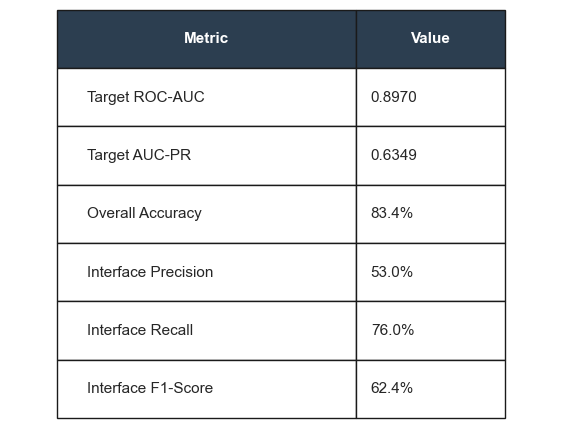

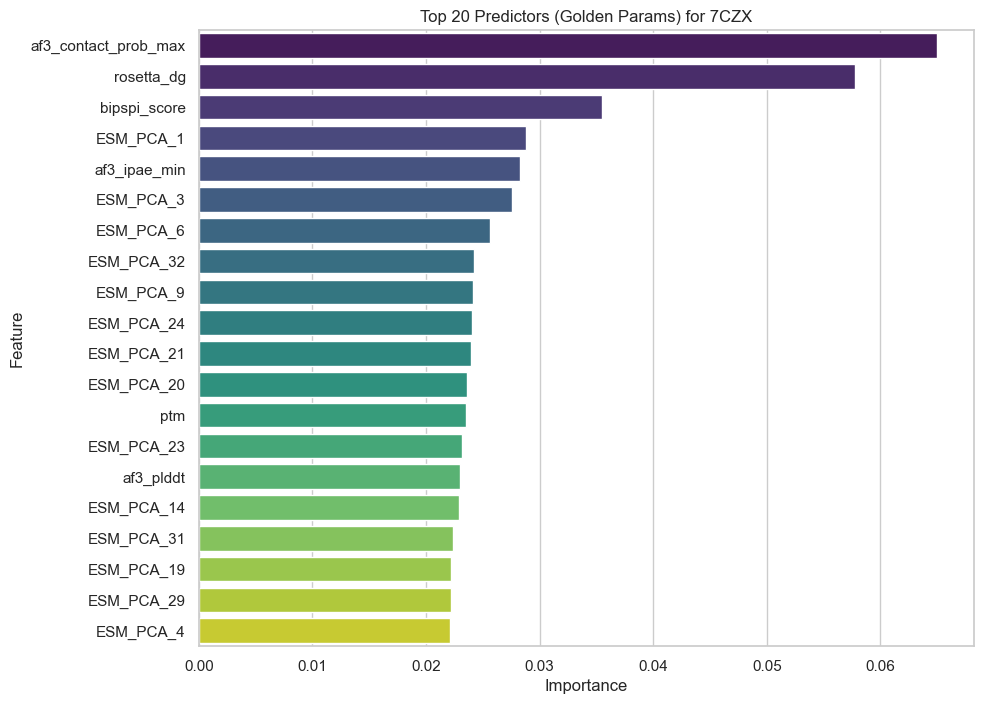

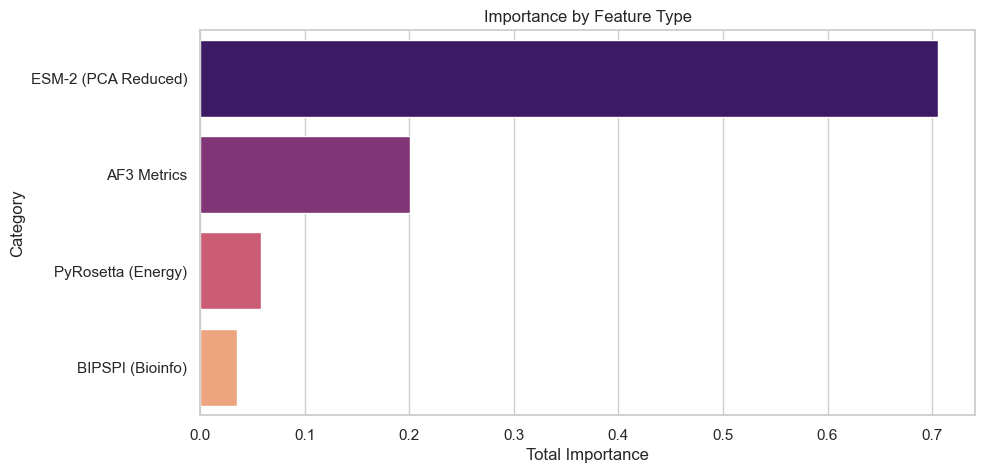


✅ VALIDATION COMPLETE ON 7CZX
📈 ROC-AUC: 0.8970
🎯 PR-AUC Score: 0.6349


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (auc, roc_auc_score, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOCAL PATHS
# ==========================================
TARGET_COMPLEX = "7CZX"  # The PDB you want to test on
BASE_DIR = os.getcwd() 

# Input files
CSV_PATH = os.path.join(BASE_DIR, "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv")
NPY_PATH = os.path.join(BASE_DIR, "esm2_embeddings_650M - Step 2.npy")

print(f"📂 Loading data for Targeted Validation on {TARGET_COMPLEX}...")
df = pd.read_csv(CSV_PATH)
raw_esm = np.load(NPY_PATH)

# Feature Groups
af3_local = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max']
af3_global = ['iptm', 'ptm', 'ranking_score']
bio_feats = ['rosetta_dg', 'bipspi_score']
feature_cols = af3_local + af3_global + bio_feats

# ==========================================
# 2. PREPROCESSING & PCA (Original Logic)
# ==========================================
# 1. Handle missing data
df[feature_cols] = df[feature_cols].fillna(0)

# 2. Filter for valid labels
mask = df['ground_truth'].notnull()
df_c = df[mask].copy()
esm_c = raw_esm[mask]

# 3. Normalize features
scaler = StandardScaler()
df_c[feature_cols] = scaler.fit_transform(df_c[feature_cols])

# 4. Dimension Reduction for ESM-2 (1280-D to 32-D)
print(f"🧬 Reducing ESM-2 to 32 Dimensions...")
pca = PCA(n_components=32, random_state=42)
esm_pca = pca.fit_transform(esm_c)
esm_labels = [f'ESM_PCA_{i+1}' for i in range(32)]

# Combine all features
X = np.hstack([df_c[feature_cols].values, esm_pca])
y = df_c['ground_truth'].astype(int).values
complex_ids = df_c['complex_id'].values
all_feat_names = feature_cols + esm_labels

# Split logic
train_mask = (complex_ids != TARGET_COMPLEX)
test_mask = (complex_ids == TARGET_COMPLEX)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ==========================================
# 3. ENSEMBLE TRAINING (GOLDEN PARAMS)
# ==========================================
print(f"🚀 Training Golden Ensemble on {X_train.shape[0]} rows...")

# Random Forest: Updated with Tournament Winner Params
rf = RandomForestClassifier(
    n_estimators=500, 
    max_depth=30, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# HistGBM: Updated with Tournament Winner Params
gbm = HistGradientBoostingClassifier(
    max_iter=300, 
    learning_rate=0.1, 
    l2_regularization=50.0, 
    random_state=42
)

rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)

# Ensemble Prediction (60/40 Weighting)
prob_rf = rf.predict_proba(X_test)[:, 1]
prob_gbm = gbm.predict_proba(X_test)[:, 1]
ensemble_probs = (0.60 * prob_rf) + (0.40 * prob_gbm)

# ==========================================
# 4. METRIC OPTIMIZATION
# ==========================================
target_roc_auc = roc_auc_score(y_test, ensemble_probs)
p, r, t = precision_recall_curve(y_test, ensemble_probs)
pr_auc = auc(r, p)

f1_array = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
best_threshold = t[np.argmax(f1_array[:-1])]
y_pred = (ensemble_probs >= best_threshold).astype(int)

metrics_data = [
    ["Target ROC-AUC", f"{target_roc_auc:.4f}"],
    ["Target AUC-PR", f"{pr_auc:.4f}"],
    ["Overall Accuracy", f"{accuracy_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Precision", f"{precision_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Recall", f"{recall_score(y_test, y_pred)*100:.1f}%"],
    ["Interface F1-Score", f"{f1_score(y_test, y_pred)*100:.1f}%"]
]

# ==========================================
# 5. VISUALIZATION (Original Formatting)
# ==========================================
print("📊 Generating Visualizations...")
sns.set_theme(style="whitegrid")

# Chart 1: Metrics Table (Original Style)
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')
table = ax.table(cellText=metrics_data, colLabels=["Metric", "Value"], loc='center', cellLoc='left', colWidths=[0.5, 0.25])
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.1, 3.5)
for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
plt.savefig(f'Performance_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 2: Top 20 Predictors
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
plt.figure(figsize=(10, 8))
top_20_fi = fi_df.sort_values('Importance', ascending=False).head(20)
sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
plt.title(f'Top 20 Predictors (Golden Params) for {TARGET_COMPLEX}')
plt.savefig(f'Importance_Individual_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 3: Categorical Importance
category_map = {
    'AF3 Metrics': af3_local + af3_global,
    'ESM-2 (PCA Reduced)': esm_labels,
    'PyRosetta (Energy)': ['rosetta_dg'],
    'BIPSPI (Bioinfo)': ['bipspi_score']
}
cat_data = []
for cat, feats in category_map.items():
    imp = fi_df[fi_df['Feature'].isin(feats)]['Importance'].sum()
    cat_data.append({'Category': cat, 'Total Importance': imp})

plt.figure(figsize=(10, 5))
sns.barplot(x='Total Importance', y='Category', data=pd.DataFrame(cat_data).sort_values('Total Importance', ascending=False), palette='magma')
plt.title('Importance by Feature Type')
plt.savefig(f'Importance_Category_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n" + "="*40)
print(f"✅ VALIDATION COMPLETE ON {TARGET_COMPLEX}")
print(f"📈 ROC-AUC: {target_roc_auc:.4f}")
print(f"🎯 PR-AUC Score: {pr_auc:.4f}")
print("="*40)

Leave-One-Out Validation (7D0D)

📂 Loading data for Targeted Validation on 7D0D...
🧬 Reducing ESM-2 to 32 Dimensions...
🚀 Training Golden Ensemble on 395285 rows...
📊 Generating Visualizations...


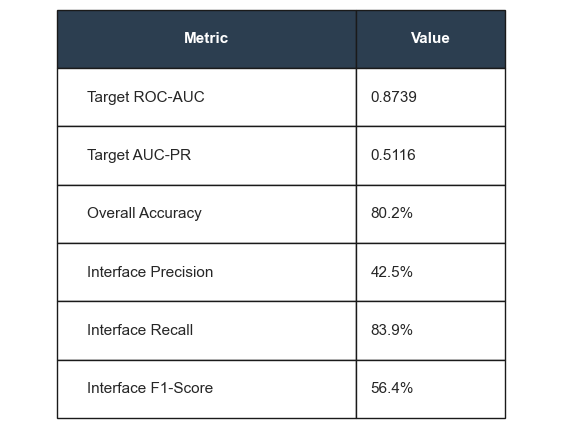

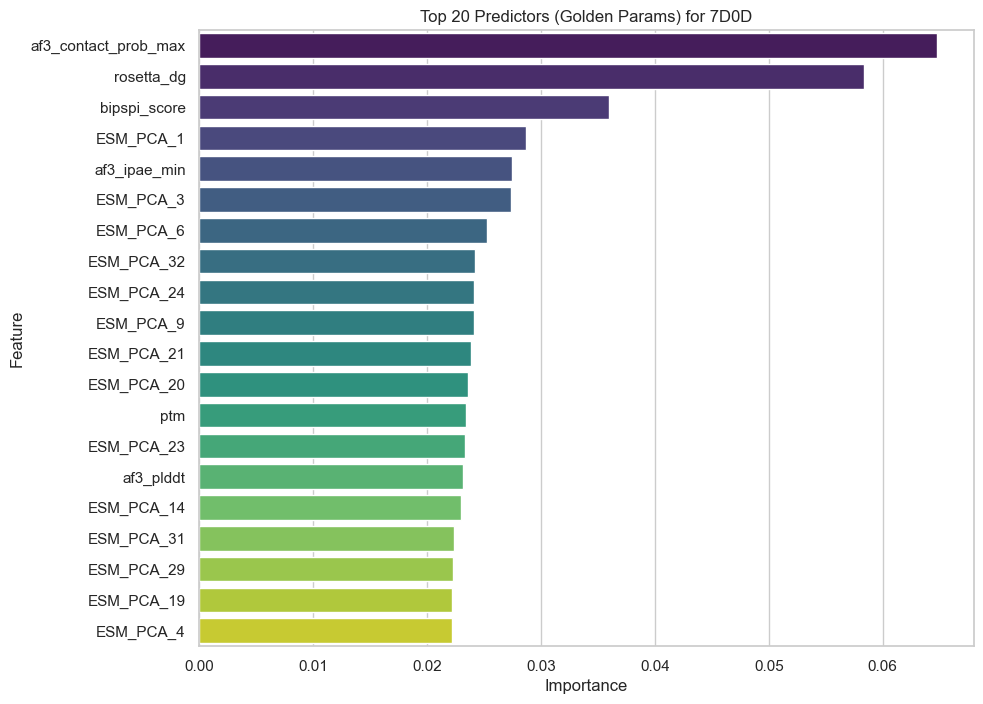

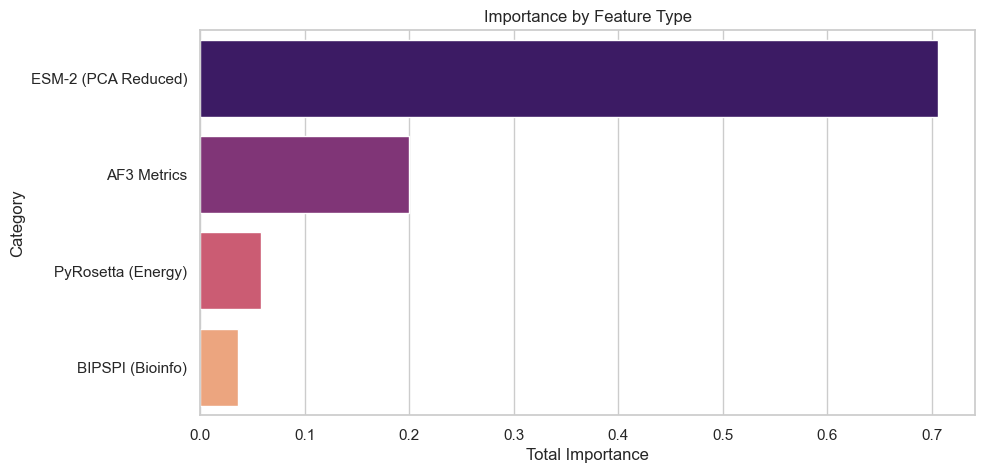


✅ VALIDATION COMPLETE ON 7D0D
📈 ROC-AUC: 0.8739
🎯 PR-AUC Score: 0.5116


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (auc, roc_auc_score, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOCAL PATHS
# ==========================================
TARGET_COMPLEX = "7D0D"  # The PDB you want to test on
BASE_DIR = os.getcwd() 

# Input files
CSV_PATH = os.path.join(BASE_DIR, "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv")
NPY_PATH = os.path.join(BASE_DIR, "esm2_embeddings_650M - Step 2.npy")

print(f"📂 Loading data for Targeted Validation on {TARGET_COMPLEX}...")
df = pd.read_csv(CSV_PATH)
raw_esm = np.load(NPY_PATH)

# Feature Groups
af3_local = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max']
af3_global = ['iptm', 'ptm', 'ranking_score']
bio_feats = ['rosetta_dg', 'bipspi_score']
feature_cols = af3_local + af3_global + bio_feats

# ==========================================
# 2. PREPROCESSING & PCA (Original Logic)
# ==========================================
# 1. Handle missing data
df[feature_cols] = df[feature_cols].fillna(0)

# 2. Filter for valid labels
mask = df['ground_truth'].notnull()
df_c = df[mask].copy()
esm_c = raw_esm[mask]

# 3. Normalize features
scaler = StandardScaler()
df_c[feature_cols] = scaler.fit_transform(df_c[feature_cols])

# 4. Dimension Reduction for ESM-2 (1280-D to 32-D)
print(f"🧬 Reducing ESM-2 to 32 Dimensions...")
pca = PCA(n_components=32, random_state=42)
esm_pca = pca.fit_transform(esm_c)
esm_labels = [f'ESM_PCA_{i+1}' for i in range(32)]

# Combine all features
X = np.hstack([df_c[feature_cols].values, esm_pca])
y = df_c['ground_truth'].astype(int).values
complex_ids = df_c['complex_id'].values
all_feat_names = feature_cols + esm_labels

# Split logic
train_mask = (complex_ids != TARGET_COMPLEX)
test_mask = (complex_ids == TARGET_COMPLEX)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ==========================================
# 3. ENSEMBLE TRAINING (GOLDEN PARAMS)
# ==========================================
print(f"🚀 Training Golden Ensemble on {X_train.shape[0]} rows...")

# Random Forest: Updated with Tournament Winner Params
rf = RandomForestClassifier(
    n_estimators=500, 
    max_depth=30, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# HistGBM: Updated with Tournament Winner Params
gbm = HistGradientBoostingClassifier(
    max_iter=300, 
    learning_rate=0.1, 
    l2_regularization=50.0, 
    random_state=42
)

rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)

# Ensemble Prediction (60/40 Weighting)
prob_rf = rf.predict_proba(X_test)[:, 1]
prob_gbm = gbm.predict_proba(X_test)[:, 1]
ensemble_probs = (0.60 * prob_rf) + (0.40 * prob_gbm)

# ==========================================
# 4. METRIC OPTIMIZATION
# ==========================================
target_roc_auc = roc_auc_score(y_test, ensemble_probs)
p, r, t = precision_recall_curve(y_test, ensemble_probs)
pr_auc = auc(r, p)

f1_array = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
best_threshold = t[np.argmax(f1_array[:-1])]
y_pred = (ensemble_probs >= best_threshold).astype(int)

metrics_data = [
    ["Target ROC-AUC", f"{target_roc_auc:.4f}"],
    ["Target AUC-PR", f"{pr_auc:.4f}"],
    ["Overall Accuracy", f"{accuracy_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Precision", f"{precision_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Recall", f"{recall_score(y_test, y_pred)*100:.1f}%"],
    ["Interface F1-Score", f"{f1_score(y_test, y_pred)*100:.1f}%"]
]

# ==========================================
# 5. VISUALIZATION (Original Formatting)
# ==========================================
print("📊 Generating Visualizations...")
sns.set_theme(style="whitegrid")

# Chart 1: Metrics Table (Original Style)
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')
table = ax.table(cellText=metrics_data, colLabels=["Metric", "Value"], loc='center', cellLoc='left', colWidths=[0.5, 0.25])
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.1, 3.5)
for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
plt.savefig(f'Performance_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 2: Top 20 Predictors
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
plt.figure(figsize=(10, 8))
top_20_fi = fi_df.sort_values('Importance', ascending=False).head(20)
sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
plt.title(f'Top 20 Predictors (Golden Params) for {TARGET_COMPLEX}')
plt.savefig(f'Importance_Individual_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 3: Categorical Importance
category_map = {
    'AF3 Metrics': af3_local + af3_global,
    'ESM-2 (PCA Reduced)': esm_labels,
    'PyRosetta (Energy)': ['rosetta_dg'],
    'BIPSPI (Bioinfo)': ['bipspi_score']
}
cat_data = []
for cat, feats in category_map.items():
    imp = fi_df[fi_df['Feature'].isin(feats)]['Importance'].sum()
    cat_data.append({'Category': cat, 'Total Importance': imp})

plt.figure(figsize=(10, 5))
sns.barplot(x='Total Importance', y='Category', data=pd.DataFrame(cat_data).sort_values('Total Importance', ascending=False), palette='magma')
plt.title('Importance by Feature Type')
plt.savefig(f'Importance_Category_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n" + "="*40)
print(f"✅ VALIDATION COMPLETE ON {TARGET_COMPLEX}")
print(f"📈 ROC-AUC: {target_roc_auc:.4f}")
print(f"🎯 PR-AUC Score: {pr_auc:.4f}")
print("="*40)